<a href="https://colab.research.google.com/github/sereenajoshy/AI-ML-Intership/blob/main/DAY%205/DAY_5.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
Lemmatizer=WordNetLemmatizer()

In [47]:
import zipfile
import os
import pandas as pd

zip_path = "/content/nlp assg.zip"
extract_path = "extracted_files"

# Extract ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all CSV files
dataframes = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_path = os.path.join(root, file)

            df = pd.read_csv(csv_path)
            dataframes.append(df)

print("Total CSV files loaded:", len(dataframes))

Total CSV files loaded: 3


In [48]:
df=dataframes[0]

In [49]:
df.head()

,text,status
0,i don't understand whats wrong with me. i don'...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,"well, i've had anxiety and panic syndrome for ...",Anxiety
3,"for the most minimal of things, like standing ...",Anxiety
4,i stay away from family and live with my roomm...,Anxiety


In [50]:
# Convert to lowercase
df['lowercase_text'] = df['text'].str.lower()

print("\nConverted Text:")
print(df['lowercase_text'].head())


Converted Text:
0    i don't understand whats wrong with me. i don'...
1    usually when i have anxiety just chatting with...
2    well, i've had anxiety and panic syndrome for ...
3    for the most minimal of things, like standing ...
4    i stay away from family and live with my roomm...
Name: lowercase_text, dtype: object


In [51]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [52]:
import nltk
from nltk.tokenize import word_tokenize


nltk.download('punkt')
df['tokens'] = df['lowercase_text'].fillna('').apply(word_tokenize)

print(df[['lowercase_text', 'tokens']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                      lowercase_text  \
0  i don't understand whats wrong with me. i don'...   
1  usually when i have anxiety just chatting with...   
2  well, i've had anxiety and panic syndrome for ...   
3  for the most minimal of things, like standing ...   
4  i stay away from family and live with my roomm...   

                                              tokens  
0  [i, do, n't, understand, whats, wrong, with, m...  
1  [usually, when, i, have, anxiety, just, chatti...  
2  [well, ,, i, 've, had, anxiety, and, panic, sy...  
3  [for, the, most, minimal, of, things, ,, like,...  
4  [i, stay, away, from, family, and, live, with,...  


In [53]:
stop_words=set(stopwords.words('english'))
print(stop_words)

{'herself', 'your', 'how', 'is', 'have', "don't", 'again', "hadn't", "doesn't", 'ain', 'all', 'through', 'she', 'so', 'shouldn', "haven't", 'needn', 'during', 'any', 'which', "you're", 'did', 'same', 'himself', 'mightn', 'been', 't', 'by', 'weren', 'then', 'my', 'theirs', 'll', 'myself', 'won', 'didn', "he's", "it's", 'up', 'or', 've', 'what', 'into', "aren't", 'd', 'doesn', "didn't", "she'd", 're', 'because', 'down', 'were', 'the', 'there', 'between', 'but', 'their', "we'd", "isn't", 'ma', 'as', 'why', 'me', 'than', 'aren', 'having', "shan't", 'this', 'with', 'are', "i'm", 'nor', 'hasn', 'not', 'doing', "mustn't", 'you', "it'd", 'isn', 'on', "it'll", 'will', 'for', 'had', "they've", 'both', "that'll", 'further', 'below', 'those', 'until', 'whom', 'wouldn', 'very', "she'll", 'out', 'them', 'more', 'am', 'above', 'ours', 'be', 'if', "mightn't", 'too', 'has', 'and', 'its', 'they', 'while', 'who', 'these', "you'd", 'our', 'y', 'shan', 'here', 'ourselves', 'does', 'haven', 'before', 'shoul

In [54]:
#stop words removal
stop_words=set(stopwords.words('english'))
df['filtered_tokens'] = df['tokens'].apply(lambda tokens_list: [word for word in tokens_list if word not in stop_words])
print(df['filtered_tokens'].head())


0    [n't, understand, whats, wrong, ., n't, know, ...
1    [usually, anxiety, chatting, someone, someone,...
2    [well, ,, 've, anxiety, panic, syndrome, years...
3    [minimal, things, ,, like, standing, someone, ...
4    [stay, away, family, live, roommate, literally...
Name: filtered_tokens, dtype: object


In [55]:
#stemming often produces non-dictionary words like:
#studies → studi
#happiness → happi

from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

df['stemmed_tokens'] = df['filtered_tokens'].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

print(df[['filtered_tokens', 'stemmed_tokens']].head(10))

                                     filtered_tokens  \
0  [n't, understand, whats, wrong, ., n't, know, ...   
1  [usually, anxiety, chatting, someone, someone,...   
2  [well, ,, 've, anxiety, panic, syndrome, years...   
3  [minimal, things, ,, like, standing, someone, ...   
4  [stay, away, family, live, roommate, literally...   
5  ['m, ecstatic, ,, got, job, literally, fits, a...   
6  ['ve, feeling, anxious, today, ,, 's, always, ...   
7  [quit, job, today, ., fucking, terrible, ., qu...   
8  [months, stuck, loop, staying, indoors, steppi...   
9  [’, resort, friends, parents, (, ’, 17, ), ., ...   

                                      stemmed_tokens  
0  [n't, understand, what, wrong, ., n't, know, f...  
1  [usual, anxieti, chat, someon, someon, physic,...  
2  [well, ,, 've, anxieti, panic, syndrom, year, ...  
3  [minim, thing, ,, like, stand, someon, 's, way...  
4  [stay, away, famili, live, roommat, liter, gam...  
5  ['m, ecstat, ,, got, job, liter, fit, around, ... 

In [56]:
#lemmatization produces meaningful words like:
#studies → study
#children → child

import nltk
from nltk.stem import WordNetLemmatizer

Lemmatizer = WordNetLemmatizer()
nltk.download('wordnet')
nltk.download('omw-1.4')

df['lemmatized_tokens'] = df['filtered_tokens'].apply(
    lambda words: [Lemmatizer.lemmatize(word) for word in words]
)

print(df[['filtered_tokens', 'lemmatized_tokens']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                     filtered_tokens  \
0  [n't, understand, whats, wrong, ., n't, know, ...   
1  [usually, anxiety, chatting, someone, someone,...   
2  [well, ,, 've, anxiety, panic, syndrome, years...   
3  [minimal, things, ,, like, standing, someone, ...   
4  [stay, away, family, live, roommate, literally...   

                                   lemmatized_tokens  
0  [n't, understand, whats, wrong, ., n't, know, ...  
1  [usually, anxiety, chatting, someone, someone,...  
2  [well, ,, 've, anxiety, panic, syndrome, year,...  
3  [minimal, thing, ,, like, standing, someone, '...  
4  [stay, away, family, live, roommate, literally...  


In [57]:
def process_text(text):
  word_tokens=word_tokenize(text)
  filtered_tokens=[word for word in word_tokens if word.lower() not in stop_words]
  lemmatized_tokens=[Lemmatizer.lemmatize(word.lower()) for word in filtered_tokens]
  return {
      "Original_Text":text,
      "Word_Tokens":word_tokens,
      "Filtered_Tokens":filtered_tokens,
      "Lemmatized_Tokens":lemmatized_tokens
  }

In [58]:
results=df['text'].apply(process_text)
processes_df=pd.DataFrame(results.tolist())
print(processes_df.head())

                                       Original_Text  \
0  i don't understand whats wrong with me. i don'...   
1  usually when i have anxiety just chatting with...   
2  well, i've had anxiety and panic syndrome for ...   
3  for the most minimal of things, like standing ...   
4  i stay away from family and live with my roomm...   

                                         Word_Tokens  \
0  [i, do, n't, understand, whats, wrong, with, m...   
1  [usually, when, i, have, anxiety, just, chatti...   
2  [well, ,, i, 've, had, anxiety, and, panic, sy...   
3  [for, the, most, minimal, of, things, ,, like,...   
4  [i, stay, away, from, family, and, live, with,...   

                                     Filtered_Tokens  \
0  [n't, understand, whats, wrong, ., n't, know, ...   
1  [usually, anxiety, chatting, someone, someone,...   
2  [well, ,, 've, anxiety, panic, syndrome, years...   
3  [minimal, things, ,, like, standing, someone, ...   
4  [stay, away, family, live, roommate, litera

In [59]:
comparison_df = df[['filtered_tokens', 'stemmed_tokens', 'lemmatized_tokens']]
comparison_df.to_csv('lemmatization_vs_stemming.csv', index=False)

In [60]:
processed_file_path="processed_nlp_dataset.csv"
processes_df.to_csv(processed_file_path,index=False)
print(f"Processed_nlp_dataset.csv")

Processed_nlp_dataset.csv


In [61]:
df['processed_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

In [62]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(df['processed_text'])

In [63]:
print("Vocabulary:")
print(vectorizer.vocabulary_)

print("\nFeature Names:")
print(vectorizer.get_feature_names_out())

print("\nBoW Matrix:")
print(bow_matrix.toarray())

print("\nShape:")
print(bow_matrix.shape)

Vocabulary:
{'understand': 7282, 'whats': 7603, 'wrong': 7731, 'know': 3981, 'freak': 2967, 'sometimes': 6414, 'like': 4125, 'right': 5856, 'laying': 4042, 'bed': 849, 'nothing': 4724, 'happening': 3301, 'ca': 1165, 'keep': 3938, 'tear': 6878, 'running': 5924, 'face': 2690, 'stupid': 6663, 'honestly': 3471, 'fine': 2825, 'earth': 2350, 'usually': 7404, 'anxiety': 546, 'chatting': 1301, 'someone': 6411, 'physically': 5103, 'need': 4633, 'start': 6552, 'feeling': 2772, 'better': 908, 'always': 476, 'worst': 7706, 'night': 4681, 'shitty': 6182, 'knowing': 3982, 'girlfriend': 3113, 'literally': 4153, 'sharing': 6152, 'still': 6596, 'feel': 2771, 'completely': 1529, 'alone': 464, 'want': 7526, 'reach': 5551, 'wake': 7514, 'nuisance': 4741, 'guy': 3257, 'sleep': 6307, 'talk': 6843, 'anyone': 556, 'asleep': 652, 'end': 2463, 'suffering': 6705, 'silence': 6249, 'sun': 6731, 'come': 1474, 'comfortable': 1479, 'tired': 7045, 'enough': 2494, 'go': 3135, 'ig': 3590, 'weird': 7586, 'unless': 7318, 

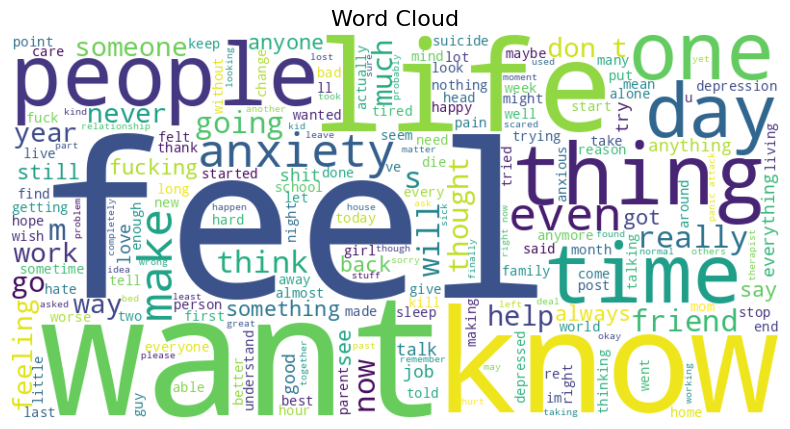

In [64]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

text_data=" ".join(df['text'].dropna())
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text_data)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud',fontsize=16)
plt.show()